In [ ]:
# IMPORT

In [47]:
import lightgbm as lgb; lgb.LGBMClassifier(random_state=0, verbose=-1)

LGBMClassifier(random_state=0, verbose=-1)

In [ ]:
# EDA

In [48]:
train.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States
1,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States
2,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States
3,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States
4,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States


In [49]:
test.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,39.0,State-gov,114055,Bachelors,13,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40.0,United-States
1,38.0,Private,254114,Some-college,10,Married-spouse-absent,Prof-specialty,Own-child,Black,Female,0,0,40.0,United-States
2,44.0,State-gov,55395,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40.0,United-States
3,47.0,Private,28035,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50.0,United-States
4,62.0,Private,186611,HS-grad,9,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,40.0,United-States


In [50]:
train.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,29304.000000,2.930400e+04,29304.000000,29304.000000,29304.000000,29304.000000
mean,38.552587,1.897488e+05,10.080842,1093.858722,86.744506,40.434036
std,13.626057,1.055250e+05,2.570824,7477.435640,401.518928,12.321306
min,-38.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.177890e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783765e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370682e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [51]:
test.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,3257.000000,3.257000e+03,3257.000000,3257.000000,3257.000000,3257.000000
mean,38.799509,1.900447e+05,10.079214,931.804728,92.336199,40.466994
std,13.904974,1.057902e+05,2.590118,6496.962999,415.732721,12.581146
min,17.000000,1.882700e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.186520e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783190e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.364360e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.033222e+06,16.000000,99999.000000,3900.000000,99.000000


In [52]:
train.tail(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
29299,28.0,Private,47168,10th,6,Never-married,Machine-op-inspct,Own-child,White,Female,0,0,40.0,United-States
29300,44.0,Local-gov,231793,Doctorate,16,Married-spouse-absent,Prof-specialty,Unmarried,White,Female,0,0,38.0,United-States
29301,41.0,Local-gov,201435,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40.0,United-States
29302,43.0,Private,137722,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,United-States
29303,22.0,Private,406978,Bachelors,13,Never-married,Exec-managerial,Other-relative,White,Female,0,0,40.0,United-States


In [53]:
train.sample(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
11532,23.0,Private,227070,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,48.0,El-Salvador
22368,76.0,Self-emp-inc,120796,9th,5,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40.0,United-States
18023,57.0,Private,107443,1st-4th,2,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40.0,Portugal
19143,57.0,Private,112840,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50.0,United-States
14558,22.0,Private,324922,HS-grad,9,Never-married,Machine-op-inspct,Not-in-family,White,Male,0,0,50.0,United-States


In [54]:
# 데이터 크기 확인
train.shape, test.shape

((29304, 14), (3257, 14))

In [55]:
# 자료형 타입 확인
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             29304 non-null  float64
 1   workclass       29304 non-null  object 
 2   fnlwgt          29304 non-null  int64  
 3   education       29304 non-null  object 
 4   education.num   29304 non-null  int64  
 5   marital.status  29304 non-null  object 
 6   occupation      29304 non-null  object 
 7   relationship    29304 non-null  object 
 8   race            29304 non-null  object 
 9   sex             29304 non-null  object 
 10  capital.gain    29304 non-null  int64  
 11  capital.loss    29304 non-null  int64  
 12  hours.per.week  29304 non-null  float64
 13  native.country  29304 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 3.1+ MB


/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future ve

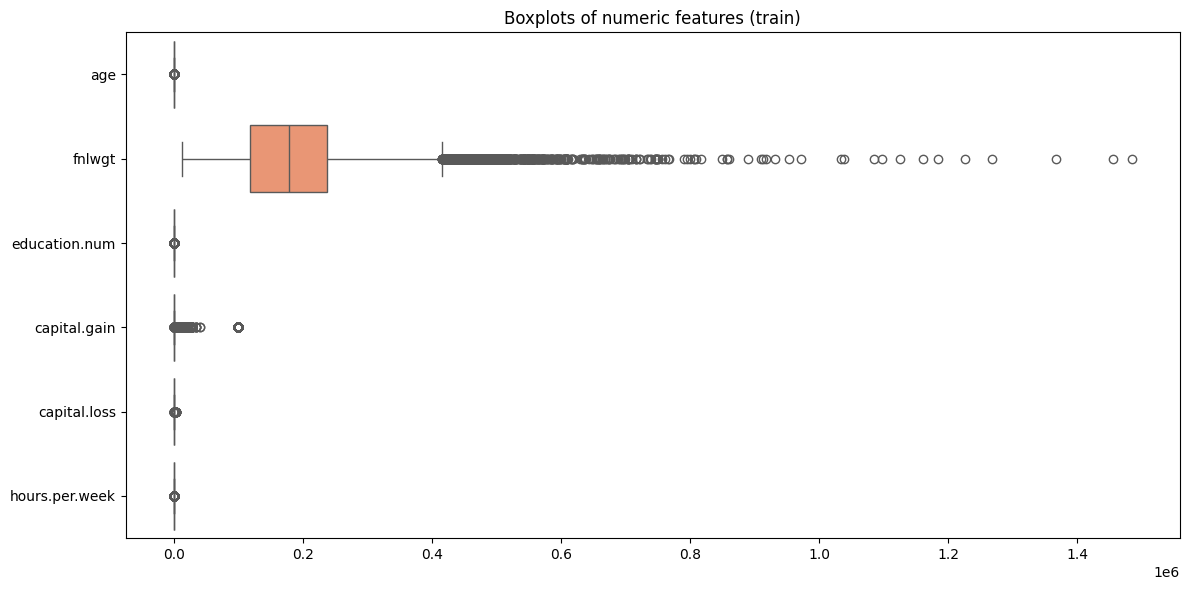

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 수치형 컬럼만 추출
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=train[numeric_cols], orient="h", palette="Set2")
plt.title("Boxplots of numeric features (train)")
plt.tight_layout()
plt.show()

In [ ]:
# 데이터 전처리

In [57]:
num_cols = ['age', 'hours.per.week']  # 수치형 데이터
cat_cols = ['workclass', 'occupation', 'native.country'] # 범주형 데이터

for c in num_cols:
    m = train[c].median()            # train 기준 중앙값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
for c in cat_cols:
    m = train[c].mode()[0]           # train 기준 최빈값
    train[c] = train[c].fillna(m)
    test[c] = test[c].fillna(m)
    
print('남은 결측치:', train.isnull().sum().sum(), test.isnull().sum().sum())

남은 결측치: 0 0


In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29304 entries, 0 to 29303
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             29304 non-null  float64
 1   workclass       29304 non-null  object 
 2   fnlwgt          29304 non-null  int64  
 3   education       29304 non-null  object 
 4   education.num   29304 non-null  int64  
 5   marital.status  29304 non-null  object 
 6   occupation      29304 non-null  object 
 7   relationship    29304 non-null  object 
 8   race            29304 non-null  object 
 9   sex             29304 non-null  object 
 10  capital.gain    29304 non-null  int64  
 11  capital.loss    29304 non-null  int64  
 12  hours.per.week  29304 non-null  float64
 13  native.country  29304 non-null  object 
dtypes: float64(2), int64(4), object(8)
memory usage: 3.1+ MB


In [59]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             3257 non-null   float64
 1   workclass       3257 non-null   object 
 2   fnlwgt          3257 non-null   int64  
 3   education       3257 non-null   object 
 4   education.num   3257 non-null   int64  
 5   marital.status  3257 non-null   object 
 6   occupation      3257 non-null   object 
 7   relationship    3257 non-null   object 
 8   race            3257 non-null   object 
 9   sex             3257 non-null   object 
 10  capital.gain    3257 non-null   int64  
 11  capital.loss    3257 non-null   int64  
 12  hours.per.week  3257 non-null   float64
 13  native.country  3257 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 356.4+ KB


In [ ]:
# train 에서 y값 분리

In [60]:
train.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,34.0,State-gov,177331,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,Black,Male,4386,0,40.0,United-States
1,58.0,Private,290661,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40.0,United-States
2,48.0,Private,125933,Some-college,10,Widowed,Exec-managerial,Unmarried,Black,Female,0,1669,38.0,United-States
3,58.0,Private,100313,Some-college,10,Married-civ-spouse,Protective-serv,Husband,White,Male,0,1902,40.0,United-States
4,41.0,Private,195661,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,54.0,United-States


In [61]:
y = train['income'].map({'<=50K': 0, '>50K': 1})   # 문자 → 0/1
y

KeyError: 'income'

In [62]:
train.shape

(29304, 14)

In [63]:
train = train.drop(columns=['id', 'income'])
train.shape

KeyError: "['id', 'income'] not found in axis"

In [64]:
test.shape

(3257, 14)

In [65]:
test_id = test['id']                                # 제출용 보관
test = test.drop(columns=['id'])

KeyError: 'id'

In [66]:
test.shape

(3257, 14)

In [67]:
all_df = pd.concat([train, test], axis=0)           # 합쳐서 인코딩
all_oh = pd.get_dummies(all_df)


In [68]:
all_df['marital.status'].unique()

array(['Married-civ-spouse', 'Widowed', 'Divorced', 'Never-married',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse'],
      dtype=object)

In [69]:
all_oh

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,34.0,177331,10,4386,0,40.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,58.0,290661,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,48.0,125933,10,0,1669,38.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,58.0,100313,10,0,1902,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41.0,195661,10,0,0,54.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,28.0,202558,10,0,0,40.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3253,52.0,94391,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3254,25.0,109526,9,0,0,38.0,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3255,36.0,242713,9,0,0,40.0,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [70]:
X = all_oh.iloc[:len(train)]                        # 다시 train 부분
X_test = all_oh.iloc[len(train):]                   # test 부분
print('인코딩 후 컬럼 수:', X.shape[1])

인코딩 후 컬럼 수: 105


In [71]:
# 검증 데이터 분할

In [72]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)
print(X_tr.shape, X_val.shape)

(23443, 105) (5861, 105)


In [73]:
# 데이터 학습

In [74]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_tr, y_tr)

RandomForestClassifier(random_state=0)

In [ ]:
# 모델 검증 지표

In [75]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
pred = rf.predict(X_val)
print(pred)
proba = rf.predict_proba(X_val)[:, 1]   # 1(>50K)일 확률 열만 (2차원 슬라이싱)
print(proba)
print('정확도 :', round(accuracy_score(y_val, pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_val, proba), 4))
print(classification_report(y_val, pred))

[1 0 1 ... 0 0 0]
[0.58 0.02 0.91 ... 0.   0.   0.  ]
정확도 : 0.8528
ROC-AUC: 0.9014
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4453
           1       0.73      0.62      0.67      1408

    accuracy                           0.85      5861
   macro avg       0.81      0.77      0.79      5861
weighted avg       0.85      0.85      0.85      5861



In [25]:
8) test 예측 & 제출 파일

In [76]:
rf.predict_proba(X_test)

array([[0.99, 0.01],
       [0.98, 0.02],
       [0.91, 0.09],
       ...,
       [0.86, 0.14],
       [0.99, 0.01],
       [0.97, 0.03]], shape=(3257, 2))

In [77]:
test_proba = rf.predict_proba(X_test)[:, 1]
submit = pd.DataFrame({'id': test_id, 'income': test_proba})
submit.to_csv('submission.csv', index=False)   # index=False 필수
submit.head(15)

,id,income
0,11574,0.01
1,15847,0.02
2,17655,0.09
3,19790,0.97
4,31812,0.04
5,7548,0.14
6,13093,0.49
7,18332,0.20
8,28474,0.27
9,4213,0.00
